In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import openpyxl
warnings.filterwarnings('ignore')

листы закодированы

Используем движок openpyxl, так как формат файла .xlsx
Отберем непустые листы

In [103]:
file_path = 'have_fun.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None, engine='openpyxl')

print("Список всех листов в файле:")
for sheet_name in all_sheets.keys():
    shape = all_sheets[sheet_name].shape
    print(f"Лист: {sheet_name}, размер: {shape[0]} строк, {shape[1]} столбцов")

Список всех листов в файле:
Лист: Ëèñò1, размер: 125124 строк, 10 столбцов
Лист: Лист1, размер: 0 строк, 0 столбцов
Лист: ÌÀÈ, размер: 0 строк, 0 столбцов
Лист: ýòî, размер: 0 строк, 0 столбцов
Лист: ÿ, размер: 0 строк, 0 столбцов
Лист: !, размер: 0 строк, 0 столбцов
Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû, размер: 125169 строк, 25 столбцов
Лист: Ëèñò3_ñìåøàííûå_òèïû, размер: 122736 строк, 10 столбцов


In [104]:
target_sheets = ['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
for name in target_sheets:
    current_columns = all_sheets[name].columns.tolist()
    print(f"Лист: {name}")
    print(f"Количество колонок: {len(current_columns)}")
    print(all_sheets[name].head(3))
    print(f"Список колонок: {current_columns}\n")


Лист: Ëèñò1
Количество колонок: 10
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.8                    82            0.0   0.0       0.0   
1            -3.0                    70            0.0   0.0       0.0   
2            -1.3                    86            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3            19.1       1010.000000 2020-01-31 02:00:00   
1            3            24.0        981.900024 2025-02-28 09:00:00   
2            2             8.8       1021.200012 2022-01-03 02:00:00   

           city  
0     Ãåëåíäæèê  
1  Áëàãîâåùåíñê  
2     Ãåëåíäæèê  
Список колонок: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']

Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Количество колонок: 25
  temperature_2m  relative_humidity_2m precipitation  rain  snowfall  \
0           -6

Второй лист имеет 15 в которых количество данных ничтожно мало, я посчитаю это за шум

In [105]:
for name in target_sheets:
    print(f"\nЛист: {name}")
    print(f"Количество ненулевых значений:\n {all_sheets[name].notna().sum()}")


Лист: Ëèñò1
Количество ненулевых значений:
 temperature_2m          123249
relative_humidity_2m    125124
precipitation           123877
rain                    125124
snowfall                125124
weathercode             125124
wind_speed_10m          123872
surface_pressure        125124
ds                      125124
city                    125124
dtype: int64

Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Количество ненулевых значений:
 temperature_2m          122036
relative_humidity_2m    122715
precipitation           122028
rain                    122685
snowfall                122685
weathercode             122684
wind_speed_10m          122335
surface_pressure        122684
ds                      122683
city                    122682
Unnamed: 10                  0
Unnamed: 11                  1
Unnamed: 12                  1
Unnamed: 13                  1
Unnamed: 14                 41
Unnamed: 15                148
Unnamed: 16                149
Unnamed: 17                147
Unnamed

Выделим 10 подтвержденных колонок встречающихся во всех листах


In [106]:
target_columns = [ 'temperature_2m', 'relative_humidity_2m', 'precipitation','rain', 'snowfall', 'weathercode','wind_speed_10m','surface_pressure','ds','city'  ]

df1 = all_sheets['Ëèñò1'][target_columns]
df2 = all_sheets['Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû'][target_columns]
df3 = all_sheets['Ëèñò3_ñìåøàííûå_òèïû'][target_columns]

df = pd.concat([df1, df2, df3], ignore_index=True)
df.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.8,82.0,0.0,0.0,0.0,3,19.1,1010.000000,2020-01-31 02:00:00,Ãåëåíäæèê
1,-3.0,70.0,0.0,0.0,0.0,3,24.0,981.900024,2025-02-28 09:00:00,Áëàãîâåùåíñê
2,-1.3,86.0,0.0,0.0,0.0,2,8.8,1021.200012,2022-01-03 02:00:00,Ãåëåíäæèê
3,19.299999,49.0,0.0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Ãåëåíäæèê
4,9.6,89.0,0.0,0.0,0.0,0,8.8,1024.400024,2025-04-16 05:00:00,Ãåëåíäæèê


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373029 entries, 0 to 373028
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        368016 non-null  object        
 1   relative_humidity_2m  370570 non-null  float64       
 2   precipitation         368392 non-null  object        
 3   rain                  370545 non-null  float64       
 4   snowfall              370545 non-null  float64       
 5   weathercode           370544 non-null  object        
 6   wind_speed_10m        368943 non-null  object        
 7   surface_pressure      370544 non-null  float64       
 8   ds                    370543 non-null  datetime64[us]
 9   city                  370542 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 28.5+ MB


Переведем все метереологические столбцы в float, время в datetime

In [108]:
df['ds'] = pd.to_datetime(df['ds'], errors='coerce')

numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373029 entries, 0 to 373028
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366251 non-null  float64       
 1   relative_humidity_2m  370570 non-null  float64       
 2   precipitation         366872 non-null  float64       
 3   rain                  370545 non-null  float64       
 4   snowfall              370545 non-null  float64       
 5   weathercode           368703 non-null  float64       
 6   wind_speed_10m        367456 non-null  float64       
 7   surface_pressure      370544 non-null  float64       
 8   ds                    370543 non-null  datetime64[us]
 9   city                  370542 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 28.5 MB


Исправим кодировку city


In [109]:
def fix_encoding(string):
    if pd.isna(string) or string.lower() == 'nan':
        return string
    try:        
        return string.encode('latin1').decode('cp1251')
    except Exception:
        return string
    
df['city'] = df['city'].apply(fix_encoding)
df['city'] = df['city'].str.strip()


print(df['city'].value_counts())
print(df['city'].unique())

city
Благовещенск       61659
Геленджик          61587
Санкт-Петербург    61368
Москва             61364
Сочи               61364
Находка            61317
Геленджикк           248
БЛАГОВЕЩЕНСК         245
Геленджи             242
благовещенск         239
Благовещенскк        230
геленджик            228
Благовещенс          226
ГЕЛЕНДЖИК            220
Сычи                   2
Мосва                  1
Счи                    1
Соч                    1
Name: count, dtype: int64
<StringArray>
[      'Геленджик',    'Благовещенск',    'БЛАГОВЕЩЕНСК',     'Благовещенс',
   'Благовещенскк',    'благовещенск',       'ГЕЛЕНДЖИК',       'геленджик',
      'Геленджикк',        'Геленджи',          'Москва',               nan,
           'Мосва',         'Находка', 'Санкт-Петербург',            'Сочи',
            'Сычи',             'Счи',             'Соч']
Length: 19, dtype: str


Исправим опечатки у городов

In [110]:
city_correction_map = {
    'БЛАГОВЕЩЕНСК': 'Благовещенск',
    'благовещенск': 'Благовещенск',
    'Благовещенскк': 'Благовещенск',
    'Благовещенс': 'Благовещенск',
    
    'ГЕЛЕНДЖИК': 'Геленджик',
    'геленджик': 'Геленджик',
    'Геленджикк': 'Геленджик',
    'Геленджи': 'Геленджик',
    
    'Мосва': 'Москва',

    'Сычи': 'Сочи',
    'Счи': 'Сочи',
    'Соч': 'Сочи'
}

df['city'] = df['city'].replace(city_correction_map)

print(df['city'].value_counts())
print(df['city'].unique())

city
Благовещенск       62599
Геленджик          62525
Санкт-Петербург    61368
Сочи               61368
Москва             61365
Находка            61317
Name: count, dtype: int64
<StringArray>
[      'Геленджик',    'Благовещенск',          'Москва',               nan,
         'Находка', 'Санкт-Петербург',            'Сочи']
Length: 7, dtype: str


Имеется 7387 дубликатов строк с информацией об одном и том же времени и в городе, а так же 2486 без времени и 2487 без указания города.

In [111]:
print(df.isna().sum())
duplicate_mask = df.duplicated(subset=['ds', 'city'], keep=False)
duplicate_count = duplicate_mask.sum()
print(f'Дубликаты времени и города: {duplicate_count}')

temperature_2m          6778
relative_humidity_2m    2459
precipitation           6157
rain                    2484
snowfall                2484
weathercode             4326
wind_speed_10m          5573
surface_pressure        2485
ds                      2486
city                    2487
dtype: int64
Дубликаты времени и города: 7387


Удалим строки без указания времени и города их нельзя восстановить. Да и потеря <1 % строк не значима, но сделает данные более чистыми

In [112]:
df = df.dropna(subset=['ds', 'city'])

Дубликаты с временем и городом, найденные выше, идентичны, поэтому можно спокойно их удалять

In [113]:

df_duplicates = df[duplicate_mask].copy()
diff_analysis = df_duplicates.groupby(['ds', 'city']).agg({'temperature_2m': lambda x: x.max() - x.min(), 'wind_speed_10m': lambda x: x.max() - x.min()})

diff_analysis.describe()

,temperature_2m,wind_speed_10m
count,2416.0,2426.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


Удаляем дубликаты

In [114]:
df = df.drop_duplicates(subset=['ds', 'city'], keep='first')

In [115]:
print(f'Пропуски до интерполяции:\n{df.isna().sum()}\n')

numeric_cols = [ 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']


df = df.sort_values(['city', 'ds'])

for col in numeric_cols:
    df[col] = df.groupby('city')[col].transform(lambda x: x.interpolate(method='linear'))

print(f'Пропуски после интерполяции:\n{df.isna().sum()}')

Пропуски до интерполяции:
temperature_2m          4289
relative_humidity_2m       5
precipitation           3681
rain                       0
snowfall                   0
weathercode             1841
wind_speed_10m          3064
surface_pressure           0
ds                         0
city                       0
dtype: int64

Пропуски после интерполяции:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
ds                      0
city                    0
dtype: int64


Анализ боксплотов:
- Температура: значения выше +60 градусов являются нереалистичными, это выбросы. Отрицательные значения могут до -50 быть допустимыми
- Влажность в норме выбросов нет
- Скорость ветра: значения выше 60 м/с почти невозможны, это точно выбросы
- Давление: значения ниже 900 или выше 1100 являются шумом для таких городов как у нас
- Осадки: найдены значение осадков до 1000 мм, что является нереалистичным. Максимум для ливня - 150 мм. Это выбросы
- Wheathercode: не являются выбросами, а представляют редкие погодные явления
- Дождь и снег выглядят физическими возможными

<Figure size 1500x1000 with 0 Axes>

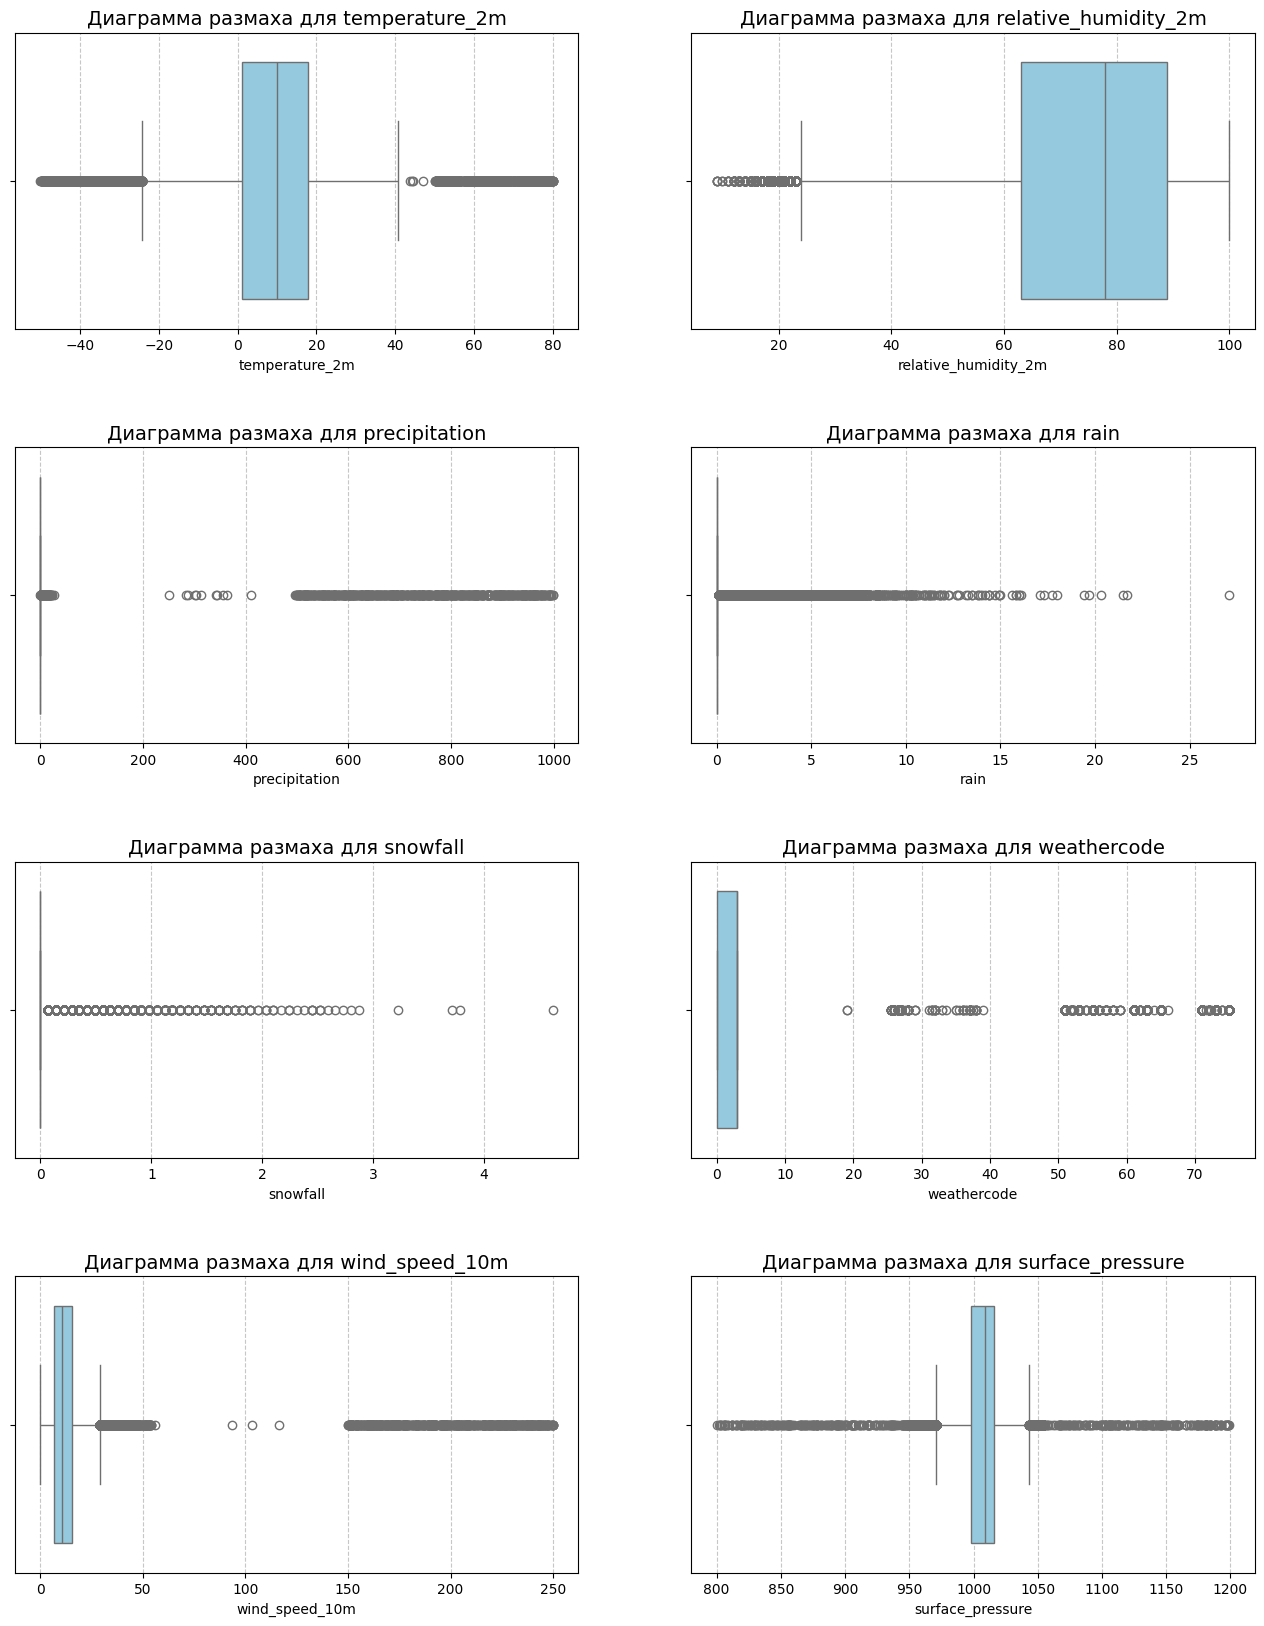

In [116]:
plt.figure(figsize=(15, 10))

plt.figure(figsize=(16, 20))
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Диаграмма размаха для {col}', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


In [117]:
df[numeric_cols].describe()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
count,368090.000000,368090.000000,368090.000000,368090.000000,368090.000000,368090.000000,368090.000000,368090.000000
mean,8.729507,74.028564,1.364284,0.093328,0.008113,11.139321,12.104266,1006.875545
std,12.265036,18.072506,31.155323,0.473841,0.064309,21.344906,10.331254,13.584594
min,-49.990098,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.185777
25%,1.050000,63.000000,0.000000,0.000000,0.000000,0.000000,6.700000,998.099976
50%,10.000000,78.000000,0.000000,0.000000,0.000000,3.000000,10.500000,1009.099976
75%,17.900000,89.000000,0.000000,0.000000,0.000000,3.000000,15.600000,1016.099976
max,79.974214,100.000000,998.260221,27.100000,4.620000,75.000000,249.928074,1199.037397


Вручную уберем очивидый мусор. Для температуры, ветра и давления считаем границы выбросов отдельно для каждого города с коэфициентом 3.0, чтобы оставить редкую реальную погоду. Автоматическую очистку не применяем к дождю снегу и осадкам, иначе эти столбы занулятся(проверял) из-за обильного количества нулей. Все пустые места восстановим линейной интерполяцией. UPDATE: Чтобы убрать резкие перепады на графиках, которые не смог поймать обычный IQR, используем метод скользящего стандартного отклонения: сравниваем каждый час со средним значением за сутки

In [118]:
import numpy as np
import pandas as pd

df.loc[df['temperature_2m'] > 50, 'temperature_2m'] = np.nan 
df.loc[df['temperature_2m'] < -55, 'temperature_2m'] = np.nan
df.loc[df['wind_speed_10m'] > 50, 'wind_speed_10m'] = np.nan
df.loc[df['precipitation'] > 100, 'precipitation'] = np.nan 
df.loc[(df['surface_pressure'] < 930) | (df['surface_pressure'] > 1080), 'surface_pressure'] = np.nan

cols_to_fix = ['temperature_2m', 'wind_speed_10m', 'surface_pressure']

final_parts = []
for city in df['city'].unique():
    city_group = df[df['city'] == city].copy().sort_values('ds')
    
    for col in cols_to_fix:
        rolling_mean = city_group[col].rolling(window=24, center=True).mean()
        rolling_std = city_group[col].rolling(window=24, center=True).std()
        

        outlier_condition = (np.abs(city_group[col] - rolling_mean) > 3 * rolling_std)
        city_group.loc[outlier_condition, col] = np.nan
        
    final_parts.append(city_group)

df = pd.concat(final_parts, ignore_index=True)

df = df.sort_values(['city', 'ds'])
all_numeric = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'surface_pressure']

for col in all_numeric:
    df[col] = df.groupby('city')[col].transform(lambda x: x.interpolate(method='linear'))

df = df.ffill().bfill()


print(df[all_numeric].describe().loc[['min', 'max']])

     temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
min      -49.121652                   9.0            0.0   0.0      0.00   
max       47.003459                 100.0           27.1  27.1      4.62   

     wind_speed_10m  surface_pressure  
min             0.0        933.446054  
max            50.0       1079.871035  


Реализовал визуализацию временного ряда и распределение температуры. Во временном ряду видна годовая цикличность. Гистограмма распределений имеет бимодальный вид, что характерно для 2 сезонаов летнего и зимнего. Основная часть значений находиться в районе 0 и в районе 15 градусов

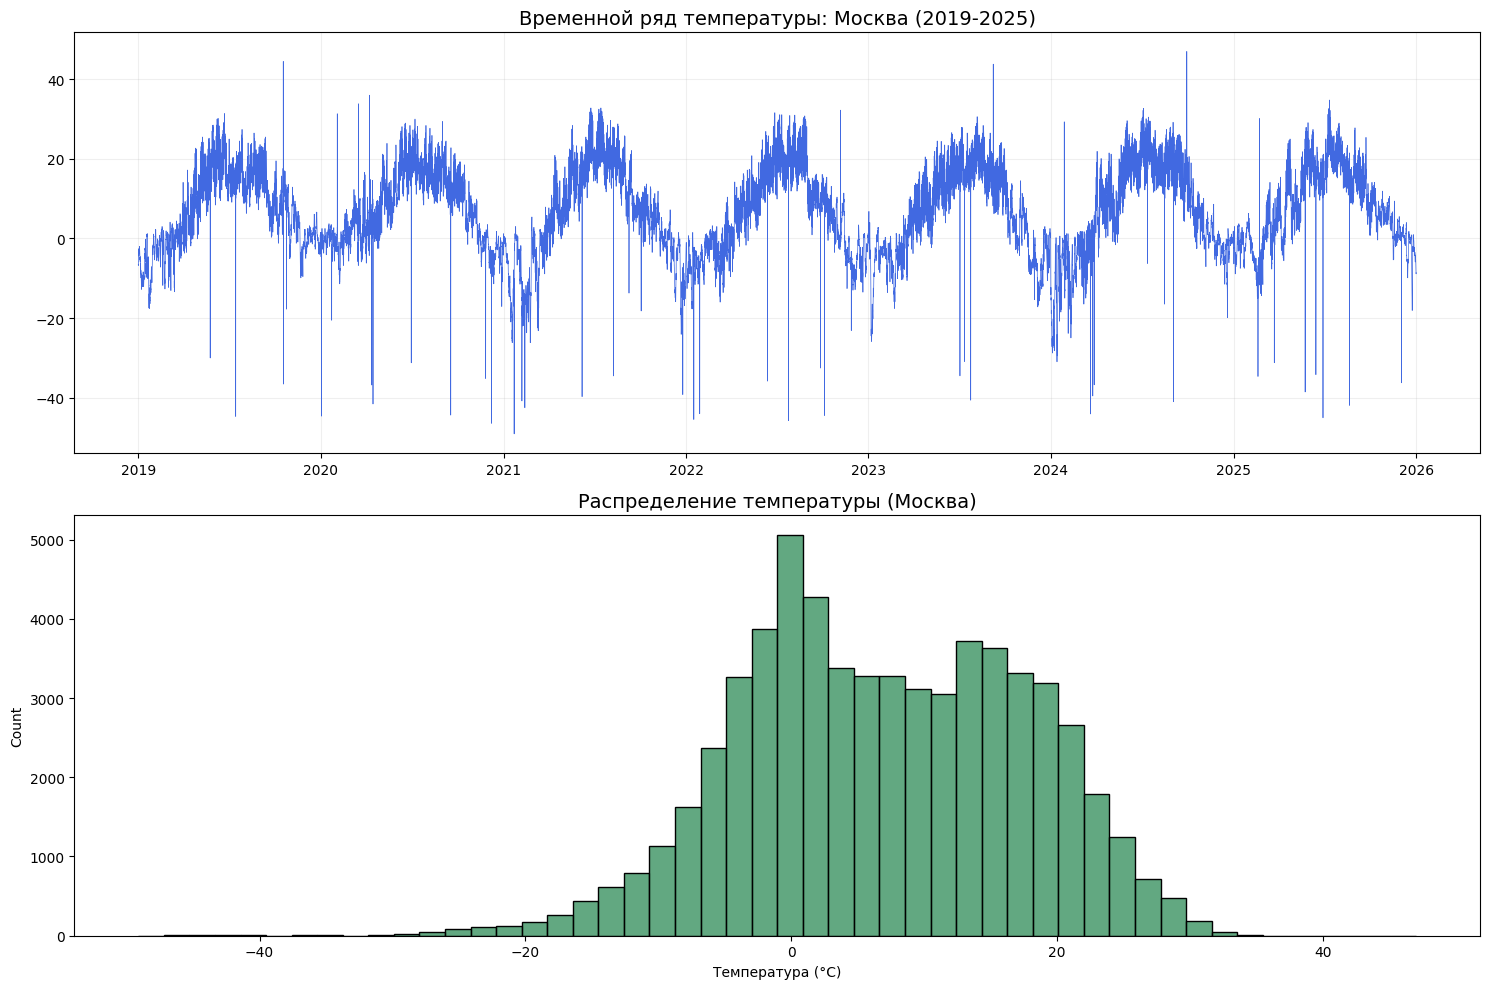

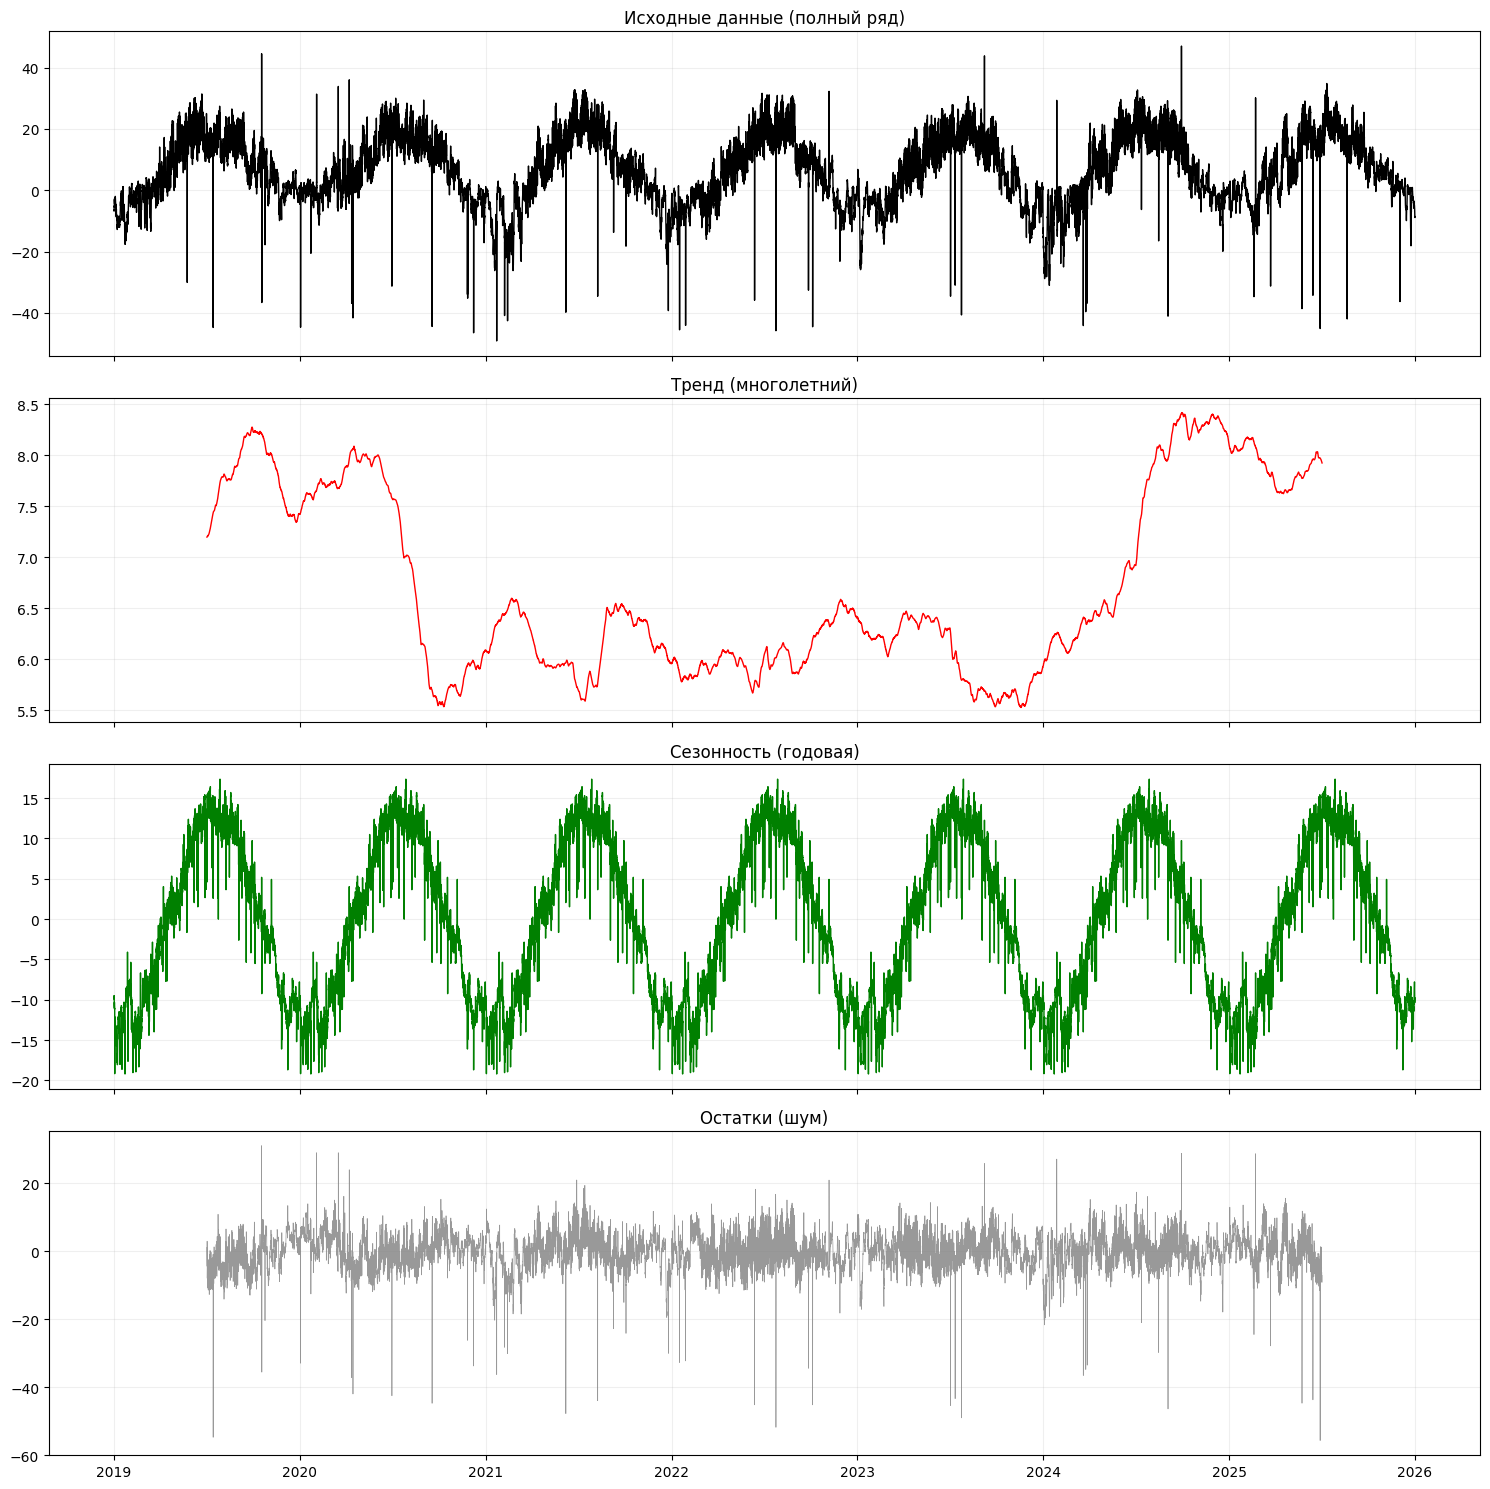

In [119]:
from statsmodels.tsa.seasonal import seasonal_decompose

target_city = 'Москва'
city_df = df[df['city'] == target_city].sort_values('ds').set_index('ds')
series = city_df['temperature_2m']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.plot(series.index, series.values, color='royalblue', linewidth=0.5)
ax1.set_title(f'Временной ряд температуры: {target_city} (2019-2025)', fontsize=14)
ax1.grid(True, alpha=0.2)

sns.histplot(series, ax=ax2, color='seagreen', bins=50)
ax2.set_title(f'Распределение температуры ({target_city})', fontsize=14)
ax2.set_xlabel('Температура (°C)')

plt.tight_layout()
plt.show()

decomp = seasonal_decompose(series, model='additive', period=8766)

fig, axes = plt.subplots(4, 1, figsize=(15, 15), sharex=True)
components = [series, decomp.trend, decomp.seasonal, decomp.resid]
titles = ['Исходные данные (полный ряд)', 'Тренд (многолетний)', 'Сезонность (годовая)', 'Остатки (шум)']
colors = ['black', 'red', 'green', 'gray']

for ax, comp, title, color in zip(axes, components, titles, colors):
    if title == 'Остатки (шум)':
        ax.plot(series.index, comp, color=color, linewidth=0.5, alpha=0.8)
    else:
        ax.plot(comp, color=color, linewidth=1)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Декомпозиция
- Тренд демонстрирует незначительные межгодовые колебания средней температуры в пределах 3 градусов
- Годовая сезонность выделена максимально четко
- Остатки содержат кратковременные погодные аномалии(причем регулярные), мы корректно отделили их от экстремальных значений 

Ряд стационарен p-value = 0.0000000183, что позволяет использовать стандартные алгоритмы машинного обучения без риска получить ложные корреляции. Спектральный анализ выявил четкие пики мощности на периодах 24, 168 и 8766 часов, подтверждая строгую физическую периодичность процессов и математически обосновывая выбор лагов для будущей модели

p-value: 0.0000000102


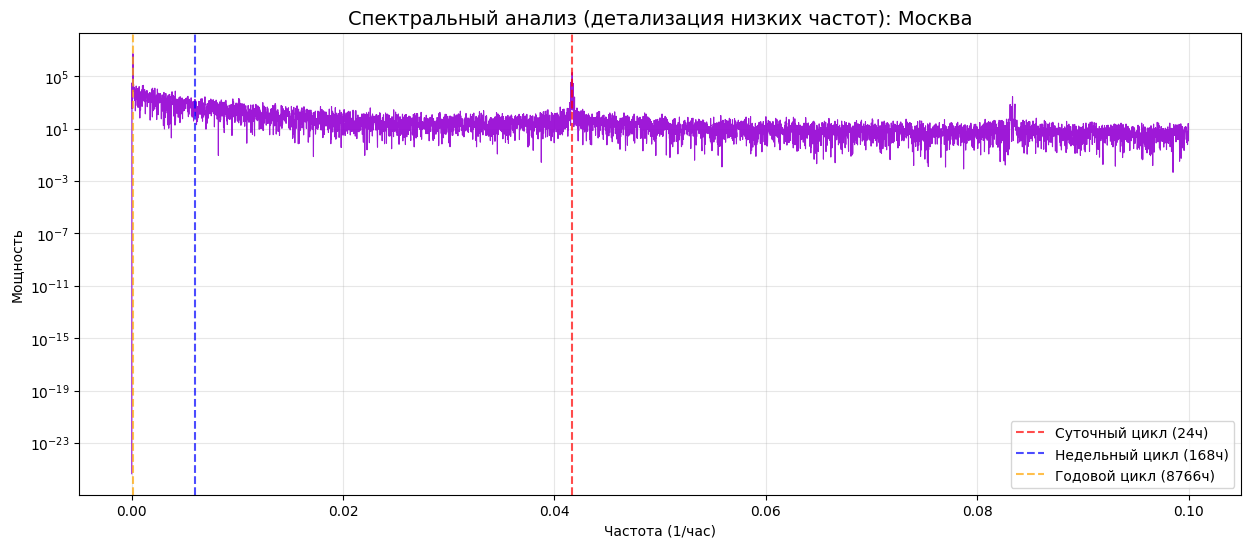

In [120]:
from statsmodels.tsa.stattools import adfuller
from scipy import signal

adf_res = adfuller(series.dropna())

print(f'p-value: {adf_res[1]:.10f}') 

frequencies, psd = signal.periodogram(series.dropna(), fs=1)

plt.figure(figsize=(15, 6))

mask = frequencies <= 0.1
plt.semilogy(frequencies[mask], psd[mask], color='darkviolet', linewidth=0.8, alpha=0.9)

plt.axvline(x=1/24, color='red', linestyle='--', alpha=0.7, label='Суточный цикл (24ч)')
plt.axvline(x=1/168, color='blue', linestyle='--', alpha=0.7, label='Недельный цикл (168ч)')
plt.axvline(x=1/8766, color='orange', linestyle='--', alpha=0.7, label='Годовой цикл (8766ч)')

plt.title(f'Спектральный анализ (детализация низких частот): {target_city}', fontsize=14)
plt.xlabel('Частота (1/час)')
plt.ylabel('Мощность')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

Разделение данных: данные до 2025 года — обучение, с 2025 — тест

In [121]:
split_date = '2025-01-01'

train = city_df.loc[city_df.index < split_date].copy()
test = city_df.loc[city_df.index >= split_date].copy()

print(f"Размер сырого трейна: {train.shape}")
print(f"Размер сырого теста: {test.shape}")

Размер сырого трейна: (52604, 9)
Размер сырого теста: (8760, 9)


    
    # 2. Обоснованные лаги (Lags)
    # 1h, 2h, 3h — инерция (спектральный хвост)
    # 12h — суточная гармоника
    # 24h — основной суточный пик
    # 168h — недельный цикл

        # 3. Оконные признаки (Rolling Windows)
    # Окно 6ч — для локальной динамики (утро/вечер)
    # Окно 24ч — суточное сглаживание

In [122]:
def extract_optimized_features(df_target, df_full):
    X = pd.DataFrame(index=df_target.index)
    
    X['hour'] = X.index.hour
    X['month'] = X.index.month
    X['day_of_week'] = X.index.dayofweek
    
    lags = [1, 2, 3, 12, 24, 168]
    for lag in lags:
        X[f'lag_{lag}h'] = df_full['temperature_2m'].shift(lag).loc[df_target.index]
    
    for w in [6, 24]:
        X[f'rolling_mean_{w}h'] = df_full['temperature_2m'].rolling(window=w).mean().loc[df_target.index]
        X[f'rolling_range_{w}h'] = (df_full['temperature_2m'].rolling(window=w).max() - df_full['temperature_2m'].rolling(window=w).min()).loc[df_target.index]
        
    decomp = seasonal_decompose(df_full['temperature_2m'], model='additive', period=8766)
    X['seasonal_component'] = decomp.seasonal.loc[df_target.index]

    return X.dropna()

X_train = extract_optimized_features(train, city_df)
X_test = extract_optimized_features(test, city_df)

y_train = train['temperature_2m'].loc[X_train.index]
y_test = test['temperature_2m'].loc[X_test.index]

print(f"Новая матрица признаков: {X_train.shape[1]} колонок.")
print(f"Выбранные лаги: 1, 2, 3, 12, 24, 168 часов.")


Новая матрица признаков: 14 колонок.
Выбранные лаги: 1, 2, 3, 12, 24, 168 часов.


Выполним поиск оптимальных гиперпараметров для модели градиентного бустинга (XGBoost) с использованием Optuna. По итогу 10 итераций были найдены лучшие параметры: количество деревьев — 445, глубина — 9 и скорость обучения — 0.086

In [123]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = XGBRegressor(**params)
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_v, y_v = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        cv_scores.append(mean_absolute_error(y_v, preds))
        
    return np.mean(cv_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

best_xgb_params = study.best_params
print("Лучшие параметры XGBoost:", best_xgb_params)

[I 2026-05-12 00:57:09,970] A new study created in memory with name: no-name-2c12fc7d-fb91-4d4b-9518-c2d824cb17c5
[I 2026-05-12 00:57:11,526] Trial 0 finished with value: 0.5197284278877903 and parameters: {'n_estimators': 356, 'max_depth': 7, 'learning_rate': 0.020588990639374253, 'subsample': 0.9897892198558189}. Best is trial 0 with value: 0.5197284278877903.
[I 2026-05-12 00:57:12,249] Trial 1 finished with value: 0.5258597351348911 and parameters: {'n_estimators': 363, 'max_depth': 4, 'learning_rate': 0.051760919401951565, 'subsample': 0.8292823708737994}. Best is trial 0 with value: 0.5197284278877903.
[I 2026-05-12 00:57:12,985] Trial 2 finished with value: 0.5439790141195197 and parameters: {'n_estimators': 160, 'max_depth': 7, 'learning_rate': 0.03208798281607376, 'subsample': 0.8305210769353426}. Best is trial 0 with value: 0.5197284278877903.
[I 2026-05-12 00:57:15,786] Trial 3 finished with value: 0.5142215782856271 and parameters: {'n_estimators': 330, 'max_depth': 9, 'lea

Лучшие параметры XGBoost: {'n_estimators': 339, 'max_depth': 9, 'learning_rate': 0.07991122665201313, 'subsample': 0.6264700716991303}


Расширяем процесс оптимизации на остальные модели: дерево решений (DecisionTree) и случайный лес (RandomForest). Функция tune_models инкапсулирует процессы поиска для каждой модели, объединяя свежие результаты тюнинга с ранее полученными параметрами XGBoost в единый словарь all_best_params

In [124]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


def tune_models(X, y):
    best_params = {}
    tscv = TimeSeriesSplit(n_splits=3)

    def dt_objective(trial):
        param = {'max_depth': trial.suggest_int('max_depth', 3, 20), 'random_state': 42}
        model = DecisionTreeRegressor(**param)
        scores = [mean_absolute_error(y.iloc[v], model.fit(X.iloc[t], y.iloc[t]).predict(X.iloc[v])) for t, v in tscv.split(X)]
        return np.mean(scores)
    
    print("DecisionTree")
    study_dt = optuna.create_study(direction='minimize')
    study_dt.optimize(dt_objective, n_trials=10)
    best_params['DT'] = study_dt.best_params

    def rf_objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'random_state': 42, 'n_jobs': -1
        }
        model = RandomForestRegressor(**param)
        scores = [mean_absolute_error(y.iloc[v], model.fit(X.iloc[t], y.iloc[t]).predict(X.iloc[v])) for t, v in tscv.split(X)]
        return np.mean(scores)

    print("RandomForest")
    study_rf = optuna.create_study(direction='minimize')
    study_rf.optimize(rf_objective, n_trials=10)
    best_params['RF'] = study_rf.best_params

    best_params['XGB'] = best_xgb_params 
    
    return best_params

all_best_params = tune_models(X_train, y_train)

[I 2026-05-12 00:57:31,059] A new study created in memory with name: no-name-308d22cf-bbb9-447e-8092-275387264e49


DecisionTree


[I 2026-05-12 00:57:31,388] Trial 0 finished with value: 0.7669062901725173 and parameters: {'max_depth': 7}. Best is trial 0 with value: 0.7669062901725173.
[I 2026-05-12 00:57:31,532] Trial 1 finished with value: 1.753594048567134 and parameters: {'max_depth': 3}. Best is trial 0 with value: 0.7669062901725173.
[I 2026-05-12 00:57:31,864] Trial 2 finished with value: 0.7062944545349463 and parameters: {'max_depth': 8}. Best is trial 2 with value: 0.7062944545349463.
[I 2026-05-12 00:57:32,479] Trial 3 finished with value: 0.6470630365276976 and parameters: {'max_depth': 16}. Best is trial 3 with value: 0.6470630365276976.
[I 2026-05-12 00:57:32,699] Trial 4 finished with value: 1.0129092218877902 and parameters: {'max_depth': 5}. Best is trial 3 with value: 0.6470630365276976.
[I 2026-05-12 00:57:33,038] Trial 5 finished with value: 0.7062944545349463 and parameters: {'max_depth': 8}. Best is trial 3 with value: 0.6470630365276976.
[I 2026-05-12 00:57:33,341] Trial 6 finished with va

RandomForest


[I 2026-05-12 00:57:37,612] Trial 0 finished with value: 0.49540488720646886 and parameters: {'n_estimators': 85, 'max_depth': 12}. Best is trial 0 with value: 0.49540488720646886.
[I 2026-05-12 00:57:40,537] Trial 1 finished with value: 0.6434641554117483 and parameters: {'n_estimators': 130, 'max_depth': 7}. Best is trial 0 with value: 0.49540488720646886.
[I 2026-05-12 00:57:42,635] Trial 2 finished with value: 1.0073936880352434 and parameters: {'n_estimators': 155, 'max_depth': 4}. Best is trial 0 with value: 0.49540488720646886.
[I 2026-05-12 00:57:48,499] Trial 3 finished with value: 0.4851592102455027 and parameters: {'n_estimators': 152, 'max_depth': 13}. Best is trial 3 with value: 0.4851592102455027.
[I 2026-05-12 00:57:53,312] Trial 4 finished with value: 0.4767945687935808 and parameters: {'n_estimators': 110, 'max_depth': 15}. Best is trial 4 with value: 0.4767945687935808.
[I 2026-05-12 00:57:55,941] Trial 5 finished with value: 0.4956148754662029 and parameters: {'n_est

In [125]:

print("Гиперпараметры:")

for model_name, params in all_best_params.items():
    print(f"Модель {model_name}: {params}")

final_models = {
    'DecisionTree': DecisionTreeRegressor(**all_best_params['DT'], random_state=42),
    'RandomForest': RandomForestRegressor(**all_best_params['RF'], random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(**all_best_params['XGB'], random_state=42)
}

Гиперпараметры:
Модель DT: {'max_depth': 16}
Модель RF: {'n_estimators': 110, 'max_depth': 15}
Модель XGB: {'n_estimators': 339, 'max_depth': 9, 'learning_rate': 0.07991122665201313, 'subsample': 0.6264700716991303}


Итоговое сопоставление прямой и рекурсивной стратегий прогнозирования. Прямая стратегия обучается под каждый час отдельно, а рекурсивная — последовательно предсказывает значения, используя собственные выходы как входы для следующего шага

In [ ]:

from sklearn.metrics import mean_absolute_error

final_models = {
    'DecisionTree': DecisionTreeRegressor(**all_best_params['DT'], random_state=42),
    'RandomForest': RandomForestRegressor(**all_best_params['RF'], random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(**all_best_params['XGB'], random_state=42)
}

HORIZON = 168 
direct_results = {m: [] for m in final_models.keys()}

name_mapping = {
    'DecisionTree': 'DT',
    'RandomForest': 'RF',
    'XGBoost': 'XGB'
}

print(f"Запуск Прямой стратегии (Direct) на {HORIZON} часов")

for h in range(1, HORIZON + 1):
    y_train_h = y_train.shift(-h).dropna()
    y_test_h = y_test.shift(-h).dropna()
    \
    X_train_h = X_train.loc[y_train_h.index]
    X_test_h = X_test.loc[y_test_h.index]
    
    for name, model_class in zip(['DecisionTree', 'RandomForest', 'XGBoost'], 
                                 [DecisionTreeRegressor, RandomForestRegressor, XGBRegressor]):
        
        optuna_key = name_mapping[name]
        params = all_best_params[optuna_key]
        
        model = model_class(**params, random_state=42)
        
        model.fit(X_train_h, y_train_h)
        preds = model.predict(X_test_h)
        direct_results[name].append(mean_absolute_error(y_test_h, preds))
    if h% 24 == 0:
        print(f"прогноз на {h} часов завершён")


print(f"Запуск динамической Рекурсии...")
rf_recursive_model = final_models['RandomForest'].fit(X_train, y_train)
dynamic_recursive_mae = []

y_test_values = y_test.values
y_test_index = y_test.index
seasonal_vals = X_test['seasonal_component'].values

for i in range(0, 100):
    if i + HORIZON > len(y_test_values): break
    
    actual = y_test_values[i : i + HORIZON]

    history = list(y_test_values[max(0, i-168) : i])
    
    if len(history) < 168:
        history = [y_test_values[0]] * (168 - len(history)) + history
        
    preds = []
    
    for h in range(HORIZON):
        curr_time = y_test_index[i] + pd.Timedelta(hours=h)
        
        row = {
            'hour': curr_time.hour,
            'month': curr_time.month,
            'day_of_week': curr_time.dayofweek,
            'lag_1h': history[-1], 'lag_2h': history[-2], 'lag_3h': history[-3],
            'lag_12h': history[-12], 'lag_24h': history[-24], 'lag_168h': history[-168],
            'rolling_mean_6h': np.mean(history[-6:]),
            'rolling_range_6h': np.max(history[-6:]) - np.min(history[-6:]),
            'rolling_mean_24h': np.mean(history[-24:]),
            'rolling_range_24h': np.max(history[-24:]) - np.min(history[-24:]),
            'seasonal_component': seasonal_vals[i + h] if (i+h) < len(seasonal_vals) else seasonal_vals[-1]
        }
        
        # Быстрое создание вектора
        feat_vector = pd.DataFrame([row])[train_cols]
        pred = rf_recursive_model.predict(feat_vector)[0]
        
        preds.append(pred)
        history.append(pred)
        
    dynamic_recursive_mae.append(np.abs(np.array(preds) - actual))

avg_recursive_mae = np.mean(dynamic_recursive_mae, axis=0)


comparison_df = pd.DataFrame(direct_results, index=[f't+{i}' for i in range(1, HORIZON + 1)])
comparison_df['RF_Recursive'] = avg_recursive_mae

print("\nСравнение MAE (Оптимизировано):")
print(comparison_df.round(3).head(24)) 

Запуск Прямой стратегии (Direct) на 168 часов


KeyboardInterrupt: 

In [72]:
X_train.columns

Index(['hour', 'month', 'day_of_week', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_12h',
       'lag_24h', 'lag_168h', 'rolling_mean_6h', 'rolling_range_6h',
       'rolling_mean_24h', 'rolling_range_24h', 'seasonal_component'],
      dtype='str')

- Наилучшую точность в рамках прямой стратегии стабильно показывают RandomForest и XGBoost. Ошибка RandomForest варьируется от 1.156 °C на первом часе до 4.388 °C через неделю
- Прямая стратегия подтвердила свою надежность на долгосрочном периоде. В то же время ошибка рекурсивной стратегии (RF_Recursive) демонстрирует аномальный скачок уже на втором шаге
- XGBoost идет практически вплотную к случайному лесу, показывая сопоставимую ошибку на отметке 168 часов, одиночное дерево решений показывает результат хуже на протяжении всего периода
- Для всех моделей прямой стратегии наблюдается естественный и плавный  рост MAE по мере увеличения горизонта прогнозирования, что подтверждает корректность выбранного подхода для предсказания на 7 дней

In [ ]:

from sklearn.metrics import r2_score, mean_absolute_percentage_error

best_model = final_models['XGBoost'].fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_true = y_test.values

def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    return np.mean(np.sign(true_diff) == np.sign(pred_diff))

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def directional_r2(y_true, y_pred):
    return r2_score(np.diff(y_true), np.diff(y_pred))

print(f"MAE:                  {mean_absolute_error(y_true, y_pred):.3f} С")
print(f"MAPE:                 {mean_absolute_percentage_error(y_true, y_pred)*100:.2f} %")
print(f"WAPE:                 {wape(y_true, y_pred):.2f} %")
print(f"Directional Accuracy: {directional_accuracy(y_true, y_pred)*100:.2f} %")
print(f"Directional R2 Score: {directional_r2(y_true, y_pred):.4f}")

Directional R2:       0.9687
MAE:                  0.348 С
MAPE:                 257277775992461.38 %
WAPE:                 3.48 %
Directional Accuracy: 73.30 %
Directional R2 Score: 0.9687


Проврка модели на горизонте t+1 подтвердила хорошее качество модели. Средняя ошибка (MAE) составила 0.348, а коэффициент детерминации ($R^2$) достиг 0.9943, что указывает на тоность аппроксимации реальных данных. Относительная погрешность WAPE зафиксирована на уровне 3.48%. Модель успешно предсказывает динамику изменения температуры: точность направления (Directional Accuracy) составила 73.30%. Экстремально высокое значение MAPE связано с  наличием в данных температур, близких к 0

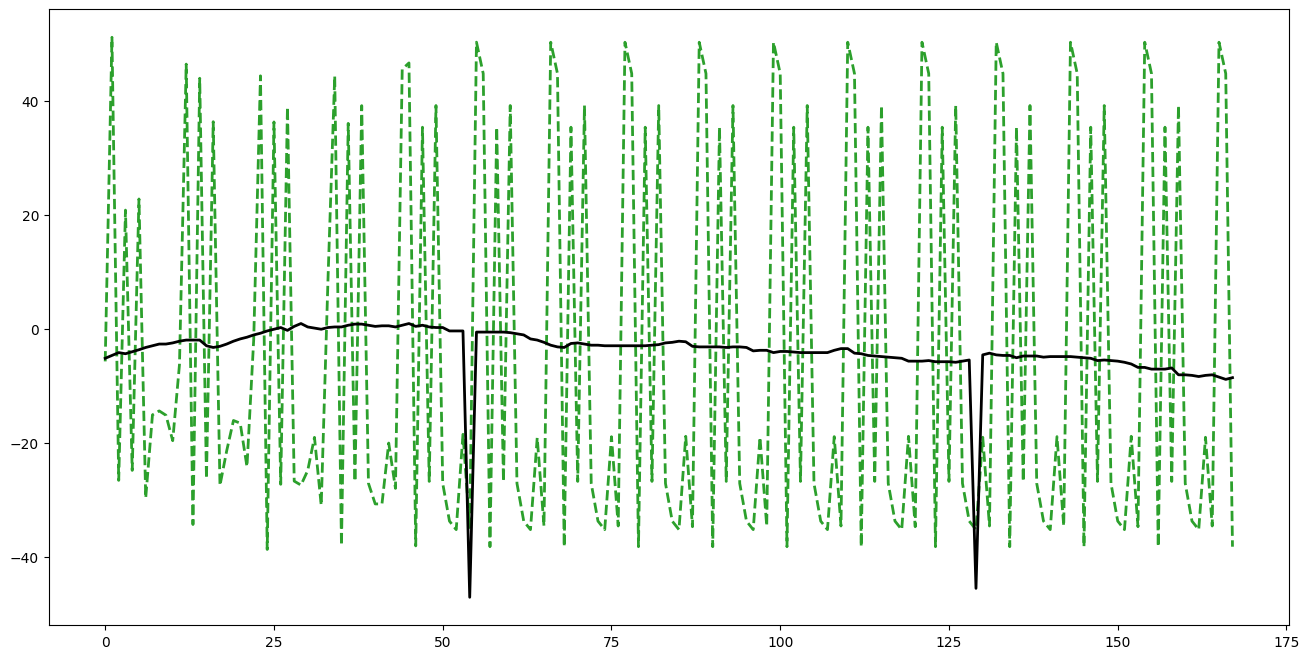

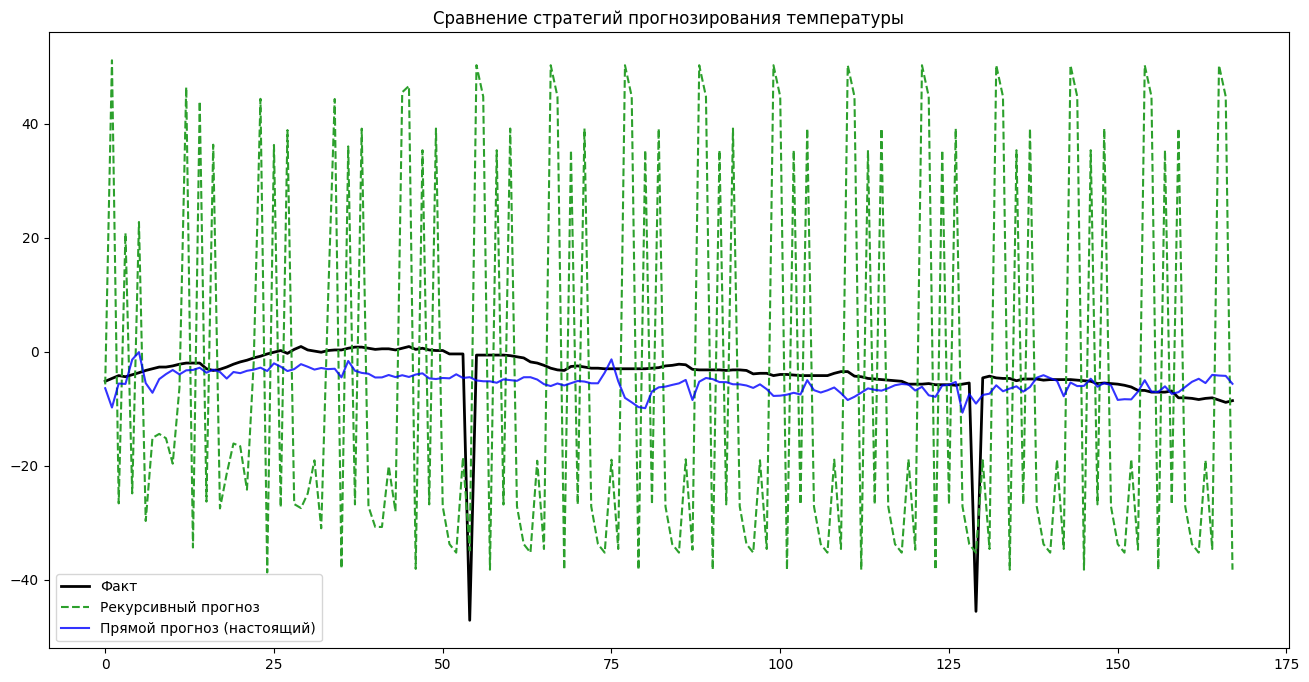

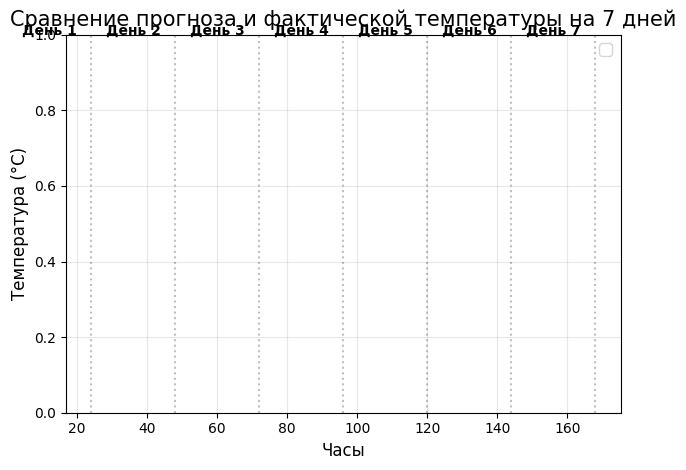

In [62]:
import matplotlib.pyplot as plt
import numpy as np

HORIZON_7 = 168

actual_weather = y_test.values[-HORIZON_7:]

start_sample = X_test.values[-HORIZON_7].reshape(1, -1)

recursive_preds = []
temp_sample = start_sample.copy()

for _ in range(HORIZON_7):
    pred = final_models['RandomForest'].predict(temp_sample)[0]
    recursive_preds.append(pred)

    temp_sample[0, 3:] = np.roll(temp_sample[0, 3:], 1)
    temp_sample[0, 3] = pred

plt.figure(figsize=(16, 8))

plt.plot(range(HORIZON_7), actual_weather, label='Факт', color='black', linewidth=2, zorder=3)

plt.plot(range(HORIZON_7), recursive_preds, label='Рекурсивный прогноз (RF)', color='#2ca02c', linestyle='--', linewidth=2)


direct_preds = []
for h in range(1, HORIZON + 1):

    y_tr_h = y_train.shift(-h).dropna()
    X_tr_h = X_train.loc[y_tr_h.index]
    
    m = RandomForestRegressor(**all_best_params['RF'], random_state=42, n_jobs=-1)
    m.fit(X_tr_h, y_tr_h)
    
    direct_preds.append(m.predict(start_sample)[0])

plt.figure(figsize=(16, 8))
plt.plot(range(HORIZON_7), actual_weather, label='Факт', color='black', linewidth=2)
plt.plot(range(HORIZON_7), recursive_preds, label='Рекурсивный прогноз', color='#2ca02c', linestyle='--')
plt.plot(range(HORIZON_7), direct_preds, label='Прямой прогноз (настоящий)', color='blue', alpha=0.8) 

plt.title('Сравнение стратегий прогнозирования температуры')
plt.legend()
plt.show()


plt.title('Сравнение прогноза и фактической температуры на 7 дней', fontsize=15)
plt.xlabel('Часы', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)


for day in range(1, 8):
    plt.axvline(x=day*24, color='gray', linestyle=':', alpha=0.5)
    plt.text(day*24 - 12, plt.ylim()[1], f'День {day}', ha='center', weight='bold')

plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()